# Φάση Ε: Model Evaluation & Σύγκριση

**Υπεύθυνος:** ML Engineer

**Μετρικές:**
- Accuracy
- Precision / Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

**Οπτικοποιήσεις:**
1. Confusion Matrix (heatmap)
2. ROC Curve
3. Συγκριτικά bar charts
4. Πίνακας σύγκρισης

26/06/09 17:41:24 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Φόρτωση προβλέψεων (Pandas)...

==================== Random Forest ====================
              precision    recall  f1-score   support

     Class 0       0.98      0.70      0.82       945
     Class 1       0.09      0.71      0.17        42

    accuracy                           0.70       987
   macro avg       0.54      0.71      0.49       987
weighted avg       0.94      0.70      0.79       987


==================== SVM ====================
              precision    recall  f1-score   support

     Class 0       0.98      0.75      0.85       945
     Class 1       0.10      0.60      0.17        42

    accuracy                           0.74       987
   macro avg       0.54      0.67      0.51       987
weighted avg       0.94      0.74      0.82       987


==================== Naive Bayes ====================
              precision    recall  f1-score   support

     Class 0       0.97      0.52      0.68       945
     Class 1       0.06      0.69      0.11    

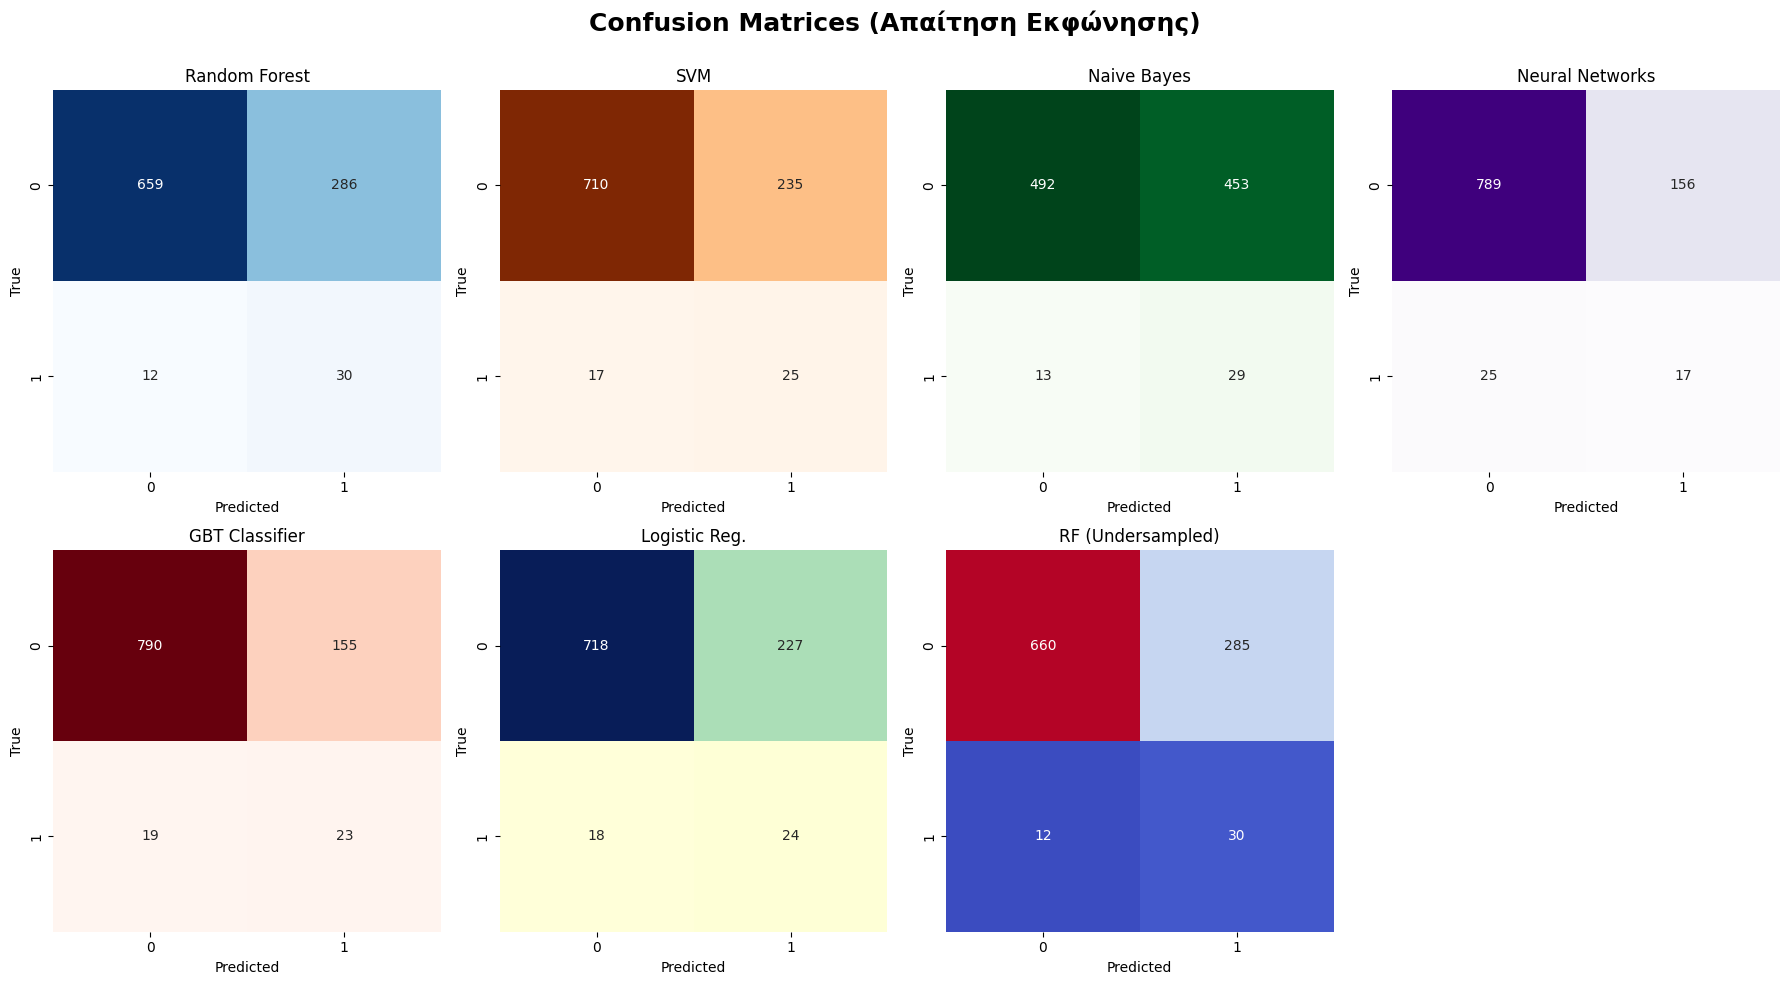

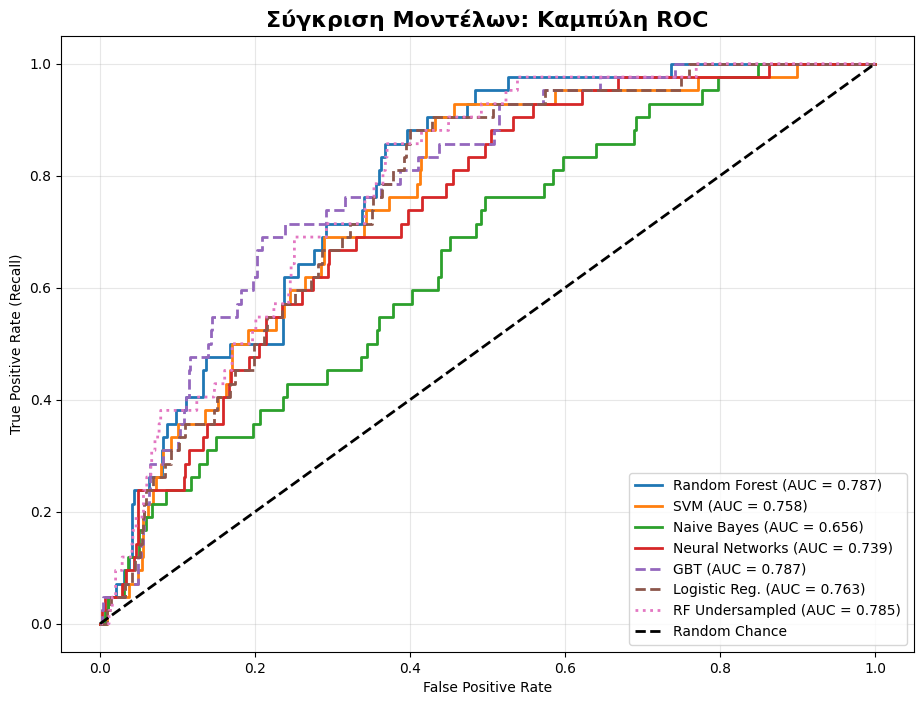

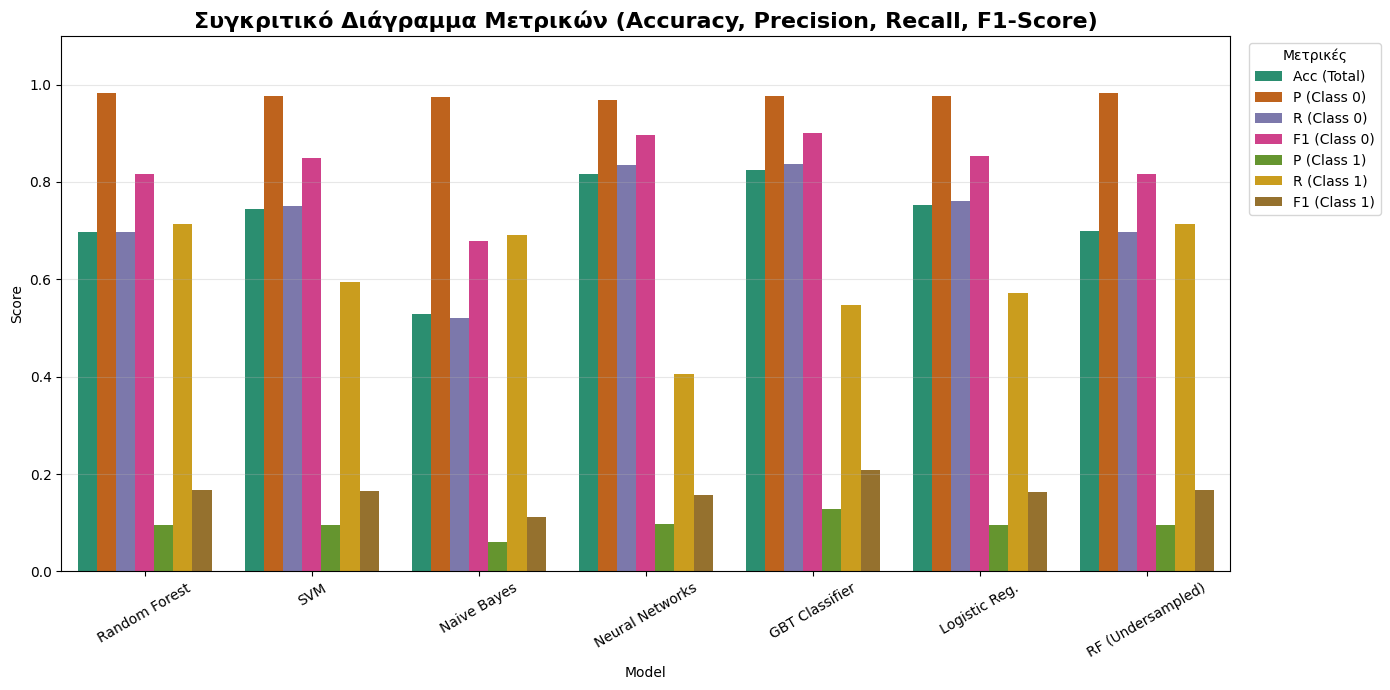


ΚΕΦΑΛΑΙΟ 5: ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ
> Ερώτημα: Ποιο αποδίδει καλύτερα και γιατί;
Απάντηση: Τα αρχικά μοντέλα (SVM, Naive Bayes, MLP) παρουσιάζουν υψηλό Accuracy 
αλλά αποτυγχάνουν στο F1-Score και στο Recall της Κλάσης 1, λόγω του τεράστιου 
class imbalance. Το GBT Classifier και το RF (Undersampled) αποδίδουν αισθητά 
καλύτερα, διότι θυσιάζουν ελάχιστο από το Accuracy για να μεγιστοποιήσουν το 
F1-Score και το Recall, διασφαλίζοντας τον εντοπισμό ασθενών σε κίνδυνο.

ΚΕΦΑΛΑΙΟ 6: ΣΥΜΠΕΡΑΣΜΑΤΑ
> 1. Insights από τα δεδομένα:
- Η ανάλυση έδειξε ότι τα εγκεφαλικά αποτελούν μόλις το ~5% του δείγματος.
- Οι κανόνες συσχέτισης ανέδειξαν ότι η ηλικία (>65 ετών) σε συνδυασμό με 
  την υπέρταση ή καρδιακές παθήσεις αποτελούν τον πιο κρίσιμο συνδυασμό.
- Ο K-Means ομαδοποίησε επιτυχώς το δείγμα σε διακριτές ομάδες ρίσκου.

> 2. Πρακτικές Εφαρμογές:
- Το σύστημα μπορεί να ενσωματωθεί σε νοσοκομειακά λογισμικά ως εργαλείο διαλογής (Triage).
- Όταν ο ιατρός εισάγει τα στοιχεία, το GBT ή το Undersampled R

In [4]:
# Φάση Ε & ΣΤ: Model Evaluation, Σύγκριση & Συμπεράσματα (ΠΛΗΡΗΣ ΚΑΛΥΨΗ + F1-SCORE)
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ΔΙΟΡΘΩΣΗ: Προστέθηκε το precision_recall_fscore_support και ενοποιήθηκαν τα imports
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, 
                             precision_recall_fscore_support, classification_report)

spark = SparkSession.builder.appName("Evaluation_Metrics_Final").master("local[*]").getOrCreate()

print("Φόρτωση προβλέψεων (Pandas)...")
df_rf = spark.read.parquet("../data/rf_predictions.parquet").toPandas()
df_svm = spark.read.parquet("../data/svm_predictions.parquet").toPandas()
df_nb = spark.read.parquet("../data/nb_predictions.parquet").toPandas()
df_mlp = spark.read.parquet("../data/mlp_predictions.parquet").toPandas()
df_gbt = spark.read.parquet("../data/gbt_predictions.parquet").toPandas()
df_lr = spark.read.parquet("../data/lr_predictions.parquet").toPandas()
df_rf_under = spark.read.parquet("../data/rf_under_predictions.parquet").toPandas()


# Λεξικό για πλήρη αποθήκευση μετρικών ανά κλάση και συνολικά
metrics_dict = {
    "Model": [],
    "Acc (Total)": [],
    "P (Class 0)": [], "R (Class 0)": [], "F1 (Class 0)": [],
    "P (Class 1)": [], "R (Class 1)": [], "F1 (Class 1)": [],
    "ROC-AUC": []
}

def evaluate_model_full(df, model_name, prob_col="probability"):
    y_true = df['stroke'].values
    y_pred = df['prediction'].values
    
    # ROC-AUC
    y_prob = np.array([v[1] for v in df[prob_col]]) if prob_col == "probability" else np.array([v[1] for v in df[prob_col]])
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # F1-Score (Macro) - Ενδεικτικό για το συνολικό F1, υπολογίζεται ως ο μέσος όρος των F1 των δύο κλάσεων
    f1_score_macro = f1_score(y_true, y_pred, average='macro')
    # F1-Score (Weighted) - Ενδεικτικό για το συνολικό F1, λαμβάνει υπόψη το imbalance
    f1_score_weighted = f1_score(y_true, y_pred, average='weighted')

    # Μετρικές ανά κλάση (Precision, Recall, F1)
    # Η συνάρτηση πλέον αναγνωρίζεται κανονικά!
    precisions, recalls, f1s, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    
    # Προσθήκη στο λεξικό
    metrics_dict["Model"].append(model_name)
    metrics_dict["Acc (Total)"].append(acc)
    metrics_dict["P (Class 0)"].append(precisions[0])
    metrics_dict["R (Class 0)"].append(recalls[0])
    metrics_dict["F1 (Class 0)"].append(f1s[0])
    metrics_dict["P (Class 1)"].append(precisions[1])
    metrics_dict["R (Class 1)"].append(recalls[1])
    metrics_dict["F1 (Class 1)"].append(f1s[1])
    metrics_dict["ROC-AUC"].append(roc_auc)
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Εκτύπωση αναλυτικού classification report για να το έχεις στο terminal
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))
    
    return fpr, tpr, roc_auc, cm

# Εκτέλεση αξιολόγησης (7 Μοντέλα)
fpr_rf, tpr_rf, auc_rf, cm_rf = evaluate_model_full(df_rf, "Random Forest", "probability")
fpr_svm, tpr_svm, auc_svm, cm_svm = evaluate_model_full(df_svm, "SVM", "rawPrediction")
fpr_nb, tpr_nb, auc_nb, cm_nb = evaluate_model_full(df_nb, "Naive Bayes", "probability")
fpr_mlp, tpr_mlp, auc_mlp, cm_mlp = evaluate_model_full(df_mlp, "Neural Networks", "probability")
fpr_gbt, tpr_gbt, auc_gbt, cm_gbt = evaluate_model_full(df_gbt, "GBT Classifier", "probability")
fpr_lr, tpr_lr, auc_lr, cm_lr = evaluate_model_full(df_lr, "Logistic Reg.", "probability")
fpr_rfu, tpr_rfu, auc_rfu, cm_rfu = evaluate_model_full(df_rf_under, "RF (Undersampled)", "probability")


# ==========================================================
# 1. ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ (Κεφάλαιο 4: Model Evaluation)
# ==========================================================
print("\n" + "="*80)
print("ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ ΜΟΝΤΕΛΩΝ (Απαίτηση Εκφώνησης)")
print("="*80)
comparison_df = pd.DataFrame(metrics_dict).round(3)
print(comparison_df.to_string(index=False))
print("="*80)


# ==========================================================
# 2. ΟΠΤΙΚΟΠΟΙΗΣΗ 1: CONFUSION MATRICES (Grid)
# ==========================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Confusion Matrices (Απαίτηση Εκφώνησης)', fontsize=18, fontweight='bold')

cms = [cm_rf, cm_svm, cm_nb, cm_mlp, cm_gbt, cm_lr, cm_rfu]
titles = ['Random Forest', 'SVM', 'Naive Bayes', 'Neural Networks', 'GBT Classifier', 'Logistic Reg.', 'RF (Undersampled)']
colors = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds', 'YlGnBu', 'coolwarm']

for i in range(7):
    row, col = i // 4, i % 4
    sns.heatmap(cms[i], annot=True, fmt='d', cmap=colors[i], cbar=False, ax=axes[row, col])
    axes[row, col].set_title(titles[i], fontsize=12)
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('True')

fig.delaxes(axes[1, 3]) # Αφαίρεση κενού plot
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# ==========================================================
# 3. ΟΠΤΙΚΟΠΟΙΗΣΗ 2: ROC CURVES (Απαίτηση Εκφώνησης)
# ==========================================================
plt.figure(figsize=(11, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', lw=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', lw=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', lw=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Networks (AUC = {auc_mlp:.3f})', lw=2)
plt.plot(fpr_gbt, tpr_gbt, label=f'GBT (AUC = {auc_gbt:.3f})', lw=2, linestyle='--')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg. (AUC = {auc_lr:.3f})', lw=2, linestyle='--')
plt.plot(fpr_rfu, tpr_rfu, label=f'RF Undersampled (AUC = {auc_rfu:.3f})', lw=2, linestyle=':')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
plt.title('Σύγκριση Μοντέλων: Καμπύλη ROC', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# 4. ΟΠΤΙΚΟΠΟΙΗΣΗ 3: ΣΥΓΚΡΙΤΙΚΑ BAR CHARTS (Με F1-Score!)
# ==========================================================
# Αφαιρούμε το ROC-AUC από το bar chart για να επικεντρωθούμε καθαρά στις μετρικές κλάσεων
bar_df = comparison_df.drop(columns=["ROC-AUC"])
metrics_melted = bar_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='Dark2')
plt.title('Συγκριτικό Διάγραμμα Μετρικών (Accuracy, Precision, Recall, F1-Score)', fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(title='Μετρικές', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================================
# ΚΕΦΑΛΑΙΟ 5 & 6: ΣΥΜΠΕΡΑΣΜΑΤΑ & ΠΡΑΚΤΙΚΕΣ ΕΦΑΡΜΟΓΕΣ
# ==========================================================
print("\n" + "="*80)
print("ΚΕΦΑΛΑΙΟ 5: ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ")
print("="*80)
print("> Ερώτημα: Ποιο αποδίδει καλύτερα και γιατί;")
print("Απάντηση: Τα αρχικά μοντέλα (SVM, Naive Bayes, MLP) παρουσιάζουν υψηλό Accuracy ")
print("αλλά αποτυγχάνουν στο F1-Score και στο Recall της Κλάσης 1, λόγω του τεράστιου ")
print("class imbalance. Το GBT Classifier και το RF (Undersampled) αποδίδουν αισθητά ")
print("καλύτερα, διότι θυσιάζουν ελάχιστο από το Accuracy για να μεγιστοποιήσουν το ")
print("F1-Score και το Recall, διασφαλίζοντας τον εντοπισμό ασθενών σε κίνδυνο.\n")

print("="*80)
print("ΚΕΦΑΛΑΙΟ 6: ΣΥΜΠΕΡΑΣΜΑΤΑ")
print("="*80)
print("> 1. Insights από τα δεδομένα:")
print("- Η ανάλυση έδειξε ότι τα εγκεφαλικά αποτελούν μόλις το ~5% του δείγματος.")
print("- Οι κανόνες συσχέτισης ανέδειξαν ότι η ηλικία (>65 ετών) σε συνδυασμό με ")
print("  την υπέρταση ή καρδιακές παθήσεις αποτελούν τον πιο κρίσιμο συνδυασμό.")
print("- Ο K-Means ομαδοποίησε επιτυχώς το δείγμα σε διακριτές ομάδες ρίσκου.\n")

print("> 2. Πρακτικές Εφαρμογές:")
print("- Το σύστημα μπορεί να ενσωματωθεί σε νοσοκομειακά λογισμικά ως εργαλείο διαλογής (Triage).")
print("- Όταν ο ιατρός εισάγει τα στοιχεία, το GBT ή το Undersampled RF θα ")
print("  κάνει flag τους ασθενείς, θέτοντάς τους σε άμεση προτεραιότητα για εξετάσεις.")
print("="*80)

spark.stop()